In [1]:
try:
    import pandas as pd
    import matplotlib.pyplot as plt
    from mplsoccer import Pitch, VerticalPitch
except:
    %pip install mplsoccer
    import pandas as pd
    import matplotlib.pyplot as plt
    from mplsoccer import Pitch, VerticalPitch    

In [2]:
eventsMessi = pd.read_csv('eventsMessi.csv')

C:\Users\yashaswi\AppData\Local\Temp\ipykernel_15528\1308467389.py:1: DtypeWarning: Columns (1,4,5,6,7,10,12,13,14,16,17,18,19,28,40,42,44,46,49,50,64,65,66,67,68,69,70,71,73,74,75,76,83,84,85,86,88,89,90,91,92,93,97,98,99,100,101,102,103,104,105,106,107,113) have mixed types. Specify dtype option on import or set low_memory=False.
  eventsMessi = pd.read_csv('eventsMessi.csv')


In [3]:
eventsMessi

,ball_receipt_outcome,ball_recovery_offensive,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,...,player_off_permanent,goalkeeper_success_out,half_end_early_video_end,goalkeeper_saved_to_post,x_start,y_start,x_end,y_end,x_carry_end,y_carry_end
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,49.1,56.9,45.5,55.3,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,61.9,34.5,77.7,67.2,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,79.7,59.7,65.1,60.9,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,77.7,58.1,94.0,45.6,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,92.0,49.6,112.4,37.7,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115196,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,97.9,63.3,NaN,NaN,NaN,NaN
115197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,31.7,15.0,NaN,NaN,NaN,NaN
115198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,...,NaN,NaN,NaN,NaN,86.8,19.6,NaN,NaN,NaN,NaN
115199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,81.8,22.2,NaN,NaN,NaN,NaN


In [4]:
seasons = sorted(eventsMessi['season'].unique().tolist())

In [5]:
col = eventsMessi.columns.tolist()

initialYears = pd.DataFrame(columns=col)
pepYears = pd.DataFrame(columns=col)
msnYears = pd.DataFrame(columns=col)
swanSong = pd.DataFrame(columns=col)

dfList = []

for season in seasons:
    if(season=='2004/2005' or season=='2005/2006'
       or season=='2006/2007' or season=='2007/2008'):
        initialYears = pd.concat([initialYears,eventsMessi[eventsMessi['season']==season]])
        
    elif(season=='2008/2009' or season=='2009/2010'
       or season=='2010/2011' or season=='2011/2012'):
        pepYears = pd.concat([pepYears,eventsMessi[eventsMessi['season']==season]])
        
    elif(season=='2012/2013' or season=='2013/2014'
       or season=='2014/2015' or season=='2015/2016'):
        msnYears = pd.concat([msnYears,eventsMessi[eventsMessi['season']==season]])
    
    else:
        swanSong = pd.concat([swanSong,eventsMessi[eventsMessi['season']==season]]) 
    

C:\Users\yashaswi\AppData\Local\Temp\ipykernel_15528\1099272839.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  initialYears = pd.concat([initialYears,eventsMessi[eventsMessi['season']==season]])
C:\Users\yashaswi\AppData\Local\Temp\ipykernel_15528\1099272839.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pepYears = pd.concat([pepYears,eventsMessi[eventsMessi['season']==season]])
C:\Users\yashaswi\AppData\Local\Temp\ipykernel_15528\1099272839.py:21: FutureWarning: The behavior of Data

## Initial Years

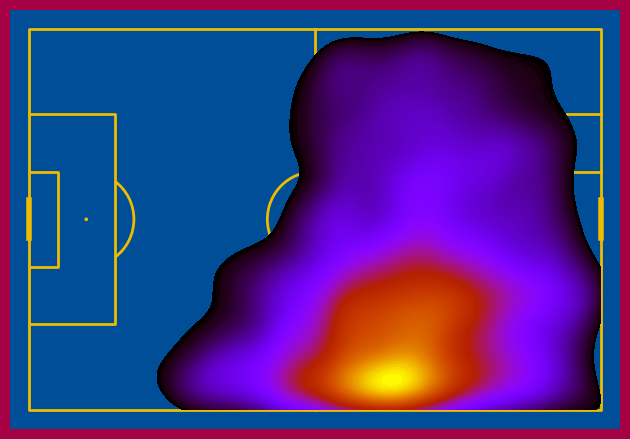

In [6]:
pitch = Pitch(pitch_type='statsbomb',pitch_color='#004d98', line_color='#edbb00')

fig, ax = pitch.draw()

fig.set_facecolor('#a50044')



kdePStart = pitch.kdeplot(initialYears['x_start'], initialYears['y_start'],fill=True,n_levels=200,cmap='gnuplot', ax=ax)

### Movement

In [7]:
iCarry = initialYears[initialYears['type']=='Carry']

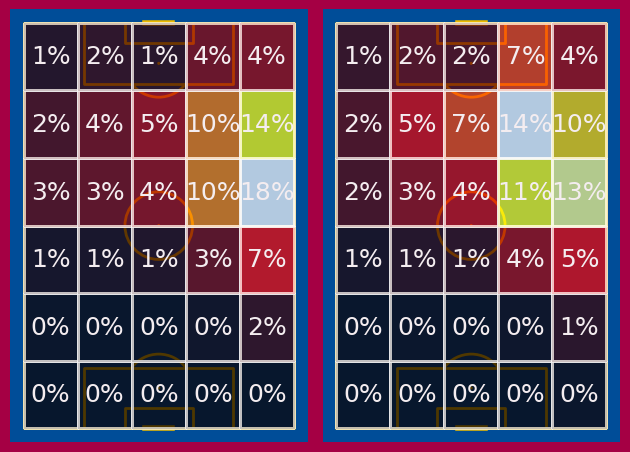

In [8]:
pitch = VerticalPitch(pitch_type='statsbomb',pitch_color='#004d98', line_color='#edbb00')
fig, axs = pitch.draw(nrows=1,ncols=2)
fig.set_facecolor('#a50044')
bin_statistic1 = pitch.bin_statistic(iCarry['x_start'], iCarry['y_start'], statistic='count', bins=(6, 5), normalize=True)
pitch.heatmap(bin_statistic1, ax=axs[0], cmap='hot', edgecolor='#f9f9f9',alpha=0.7)
labels = pitch.label_heatmap(bin_statistic1, color='#f4edf0', fontsize=18,
                             ax=axs[0], ha='center', va='center',
                             str_format='{:.0%}')

bin_statistic2 = pitch.bin_statistic(iCarry['x_carry_end'], iCarry['y_carry_end'], statistic='count', bins=(6, 5), normalize=True)
pitch.heatmap(bin_statistic2, ax=axs[1], cmap='hot', edgecolor='#f9f9f9',alpha=0.7)
labels = pitch.label_heatmap(bin_statistic2, color='#f4edf0', fontsize=18,
                             ax=axs[1], ha='center', va='center',
                             str_format='{:.0%}')

In [9]:
iyDribbles = initialYears[initialYears['type']=="Dribble"]
iyASDribbles = iyDribbles[iyDribbles['dribble_outcome']=='Complete']
iyNDribbles = iyASDribbles[iyASDribbles['dribble_nutmeg']==True]
iySDribbles = iyASDribbles[iyASDribbles['dribble_nutmeg'].isna()]
iyUDribbles = iyDribbles[iyDribbles['dribble_outcome']=='Incomplete']

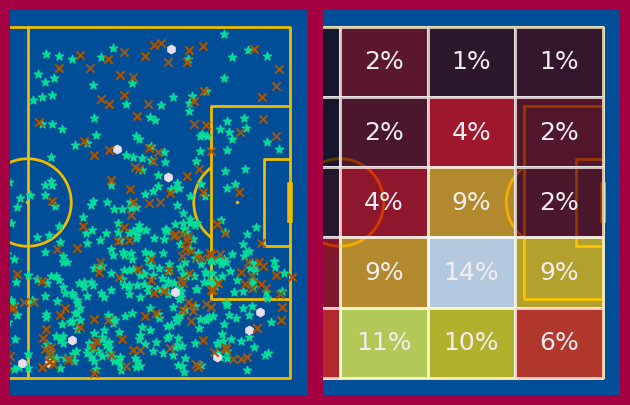

In [10]:
pitch = Pitch(pitch_type='statsbomb',pitch_color='#004d98', line_color='#edbb00',half=True)

fig, axs = pitch.draw(nrows=1,ncols=2)

fig.set_facecolor('#a50044')

sDribbles = pitch.scatter(iySDribbles['x_start'], iySDribbles['y_start'],
                   marker='*',
                   c='#00dd98',
                   ax=axs[0])

nDribbles = pitch.scatter(iyNDribbles['x_start'], iyNDribbles['y_start'],
                   marker='h',
                   c='#ebddee',
                   ax=axs[0])

uDribbles = pitch.scatter(iyUDribbles['x_start'], iyUDribbles['y_start'],
                   marker='x',
                   c='#AA5500',
                   ax=axs[0])

bin_statistic = pitch.bin_statistic(iyASDribbles['x_start'], iyASDribbles['y_start'], statistic='count', bins=(6, 5), normalize=True)
pitch.heatmap(bin_statistic, ax=axs[1], cmap='hot', edgecolor='#f9f9f9',alpha=0.7)
labels = pitch.label_heatmap(bin_statistic, color='#f4edf0', fontsize=18,
                             ax=axs[1], ha='center', va='center',
                             str_format='{:.0%}')

### Passing

In [11]:
passesIY = initialYears[initialYears['type']=='Pass']
sPIY = passesIY[passesIY['pass_outcome'].isna()]

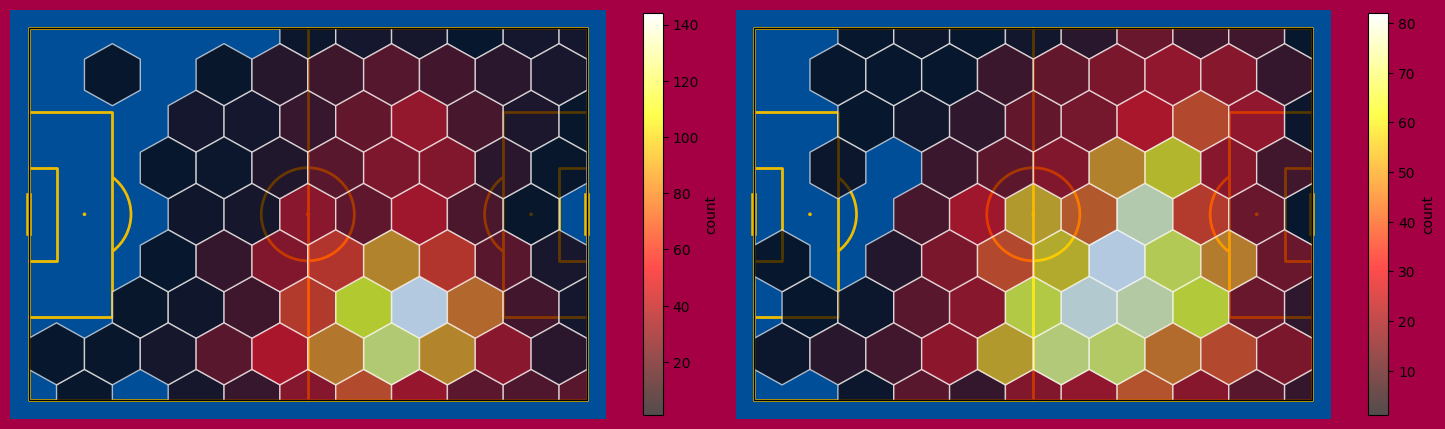

In [12]:
pitch = Pitch(pitch_type='statsbomb',pitch_color='#004d98', line_color='#edbb00')
fig, axs = pitch.draw(nrows=1, ncols=2,figsize=(15, 7))

fig.set_facecolor('#a50044')
psHexbin = pitch.hexbin(sPIY['x_start'], sPIY['y_start'], ax=axs[0], edgecolors='#f4f4f4',
                      alpha=0.7, gridsize=(10,4), cmap='hot')
peHexbin = pitch.hexbin(sPIY['x_end'], sPIY['y_end'], ax=axs[1], edgecolors='#f4f4f4',
                      alpha=0.7, gridsize=(10,4), cmap='hot')

cbar1 = fig.colorbar(psHexbin, ax=axs[0], shrink=0.6,label='count')
cbar2 = fig.colorbar(peHexbin, ax=axs[1], shrink=0.6,label='count')

In [13]:
topRecip = sPIY['pass_recipient'].value_counts().rename_axis('player_name').reset_index(name='counts').head(5)
topRecip

,player_name,counts
0,Xavier Hernández Creus,354
1,Anderson Luís de Souza,297
2,Ronaldo de Assis Moreira,284
3,Andrés Iniesta Luján,160
4,Samuel Eto''o Fils,157


### Playmaking

In [14]:
from matplotlib.patches import Circle
circH = Circle((120.0, 40.0), radius = 15,color='red')
circV = Circle((40.0, 120.0), radius = 15,color='red')

In [15]:
iyDangerPass = [row['id'] for index,row in sPIY.iterrows() if ((circH.contains_point([row['x_end'],row['y_end']])==True) or 
                                                             (circV.contains_point([row['x_end'],row['y_end']])==True))]

In [16]:
iyDangerPasses = sPIY[sPIY['id'].isin(iyDangerPass)]

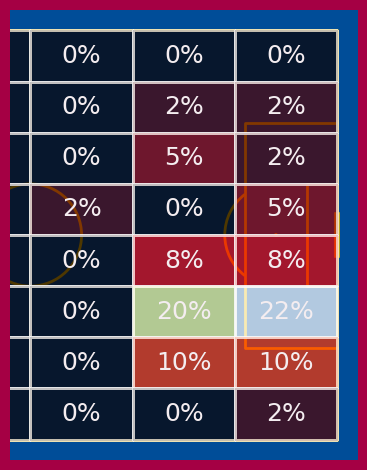

In [17]:
pitch = Pitch(pitch_type='statsbomb',pitch_color='#004d98', line_color='#edbb00',half=True)

fig, ax = pitch.draw()
fig.set_facecolor('#a50044')

bin_statistic = pitch.bin_statistic(iyDangerPasses['x_start'], iyDangerPasses['y_start'], statistic='count', bins=(6, 8), normalize=True)
pitch.heatmap(bin_statistic, ax=ax, cmap='hot', edgecolor='#f9f9f9',alpha=0.7)
labels = pitch.label_heatmap(bin_statistic, color='#f4edf0', fontsize=18,
                             ax=ax, ha='center', va='center',
                             str_format='{:.0%}')

#### Assists

In [18]:
iyAssists = initialYears[initialYears['pass_goal_assist']==True]

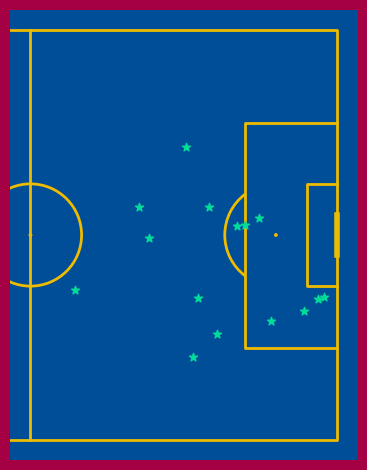

In [19]:
pitch = Pitch(pitch_type='statsbomb',pitch_color='#004d98', line_color='#edbb00',half=True)

fig, axs = pitch.draw()

fig.set_facecolor('#a50044')

sDribbles = pitch.scatter(iyAssists['x_start'], iyAssists['y_start'],
                   marker='*',
                   c='#00dd98',
                   ax=axs)

In [20]:
gsAssisted = iyAssists['pass_recipient'].value_counts().rename_axis('player_name').reset_index(name='counts')

In [21]:
gsAssisted

,player_name,counts
0,Samuel Eto''o Fils,6
1,Thierry Henry,3
2,Giovani dos Santos Ramírez,2
3,Carles Puyol i Saforcada,1
4,Bojan Krkíc Pérez,1
5,Andrés Iniesta Luján,1
6,Xavier Hernández Creus,1


In [22]:
setpiece = ["Corner", "Throw-in","Free Kick"]

In [23]:
spAssists = iyAssists[iyAssists['pass_type'].isin(setpiece)]

In [24]:
spAssists

,ball_receipt_outcome,ball_recovery_offensive,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,...,player_off_permanent,goalkeeper_success_out,half_end_early_video_end,goalkeeper_saved_to_post,x_start,y_start,x_end,y_end,x_carry_end,y_carry_end


### Goal Scoring

In [25]:
iyGoals = initialYears[initialYears['shot_outcome']=='Goal']

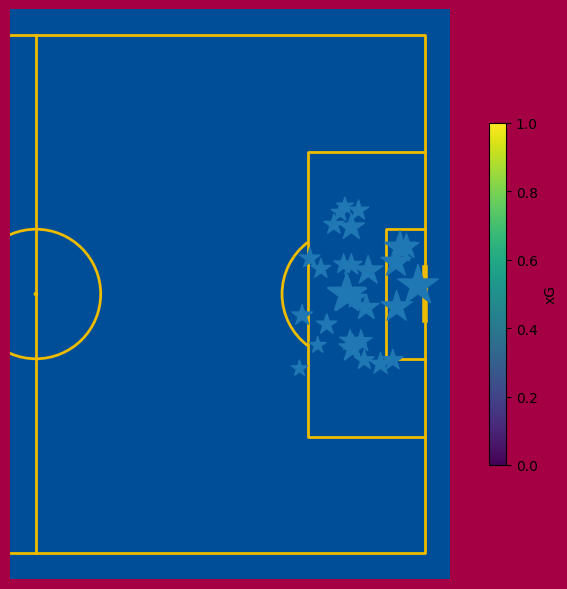

In [34]:
pitch = Pitch(pitch_type='statsbomb',pitch_color='#004d98', line_color='#edbb00',half=True)

fig, axs = pitch.draw(figsize=(8,6))

fig.set_facecolor('#a50044')

iyGoalsPlot = pitch.scatter(iyGoals['x_start'], iyGoals['y_start'],
                   marker='*',
                   cmap='hot',
                   s=(iyGoals['shot_statsbomb_xg']*900) + 100,
                   ax=axs)

cbar = fig.colorbar(iyGoalsPlot, ax=axs, shrink=0.6,label='xG')